# 傅里叶变换与傅里叶逆变换：SymPy 和 Matplotlib 演示

**目标。** 本 Notebook 说明连续时间傅里叶变换（Continuous-Time Fourier Transform, CTFT）及其逆变换的定义、典型应用与工程意义；随后以**高斯信号**为例，使用 `sympy` 进行符号推导，使用 `matplotlib` 绘制支持中文标注的时域、频域和重构结果图。

> 运行环境建议：Python 3.10+，SymPy，NumPy，Matplotlib。若系统未安装中文字体，图中的中文可能无法正常显示；本 Notebook 已尝试按优先级自动选择可用的中文字体。

## 1. 定义与变换约定

对于满足适当可积性条件的连续时间信号 $x(t)$，常用的**角频率**（单位：rad/s）形式为：

$$
X(\omega)=\int_{-\infty}^{\infty}x(t)\,e^{-j\omega t}\,\mathrm{d}t,
$$

$$
x(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty}X(\omega)\,e^{j\omega t}\,\mathrm{d}\omega.
$$

其中，$t$ 为时间，$\omega$ 为角频率，$j^2=-1$。傅里叶变换把信号由**时间域**映射到**频率域**；傅里叶逆变换则在满足条件时将频域表示还原为原信号。

本 Notebook 调用 SymPy 的 `fourier_transform` 与 `inverse_fourier_transform`。SymPy 使用普通频率 $k$（单位：Hz）的约定：

$$
F(k)=\int_{-\infty}^{\infty}f(t)e^{-2\pi i t k}\,\mathrm{d}t,\qquad
f(t)=\int_{-\infty}^{\infty}F(k)e^{2\pi i t k}\,\mathrm{d}k.
$$

两种约定的对应关系为 $\omega=2\pi k$，即 $F(k)=X(2\pi k)$。SymPy 的上述定义见官方文档。[1]

## 2. 应用场景与意义

傅里叶变换的核心价值在于：它将“信号随时间如何变化”的问题，转化为“信号由哪些频率成分构成、各频率成分有多强”的问题。许多系统在频域中具有更简单的描述，例如线性时不变系统的卷积运算会转化为频域乘法。

| 场景 | 傅里叶变换的作用 | 工程意义 |
|---|---|---|
| 音频与语音处理 | 识别基频、谐波和噪声的频谱分布 | 用于均衡、降噪、压缩与特征提取 |
| 图像处理 | 将二维图像分解为不同空间频率成分 | 便于锐化、模糊、纹理分析与压缩 |
| 通信系统 | 分析带宽、调制信号与频谱占用 | 支撑滤波器设计、信道分配与抗干扰 |
| 控制与振动 | 观察系统对各频率输入的响应 | 用于共振识别、故障诊断和频率响应分析 |
| 信号重构 | 由频域系数恢复时域波形 | 为频域滤波、采样理论和频谱修改提供基础 |

> **重要理解：** 频域并不是“另一条信号”，而是同一信号在另一组基函数（复指数）下的表示。逆变换说明这种表示在相应条件下是可逆的。

## 3. 导入库并设置中文绘图字体

下面的代码会检查本机可用字体，并优先选择常见的中文字体。`axes.unicode_minus=False` 用于正确显示坐标轴中的负号。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sympy as sp
from sympy import (
    exp, fourier_transform, inverse_fourier_transform,
    symbols, simplify, pi
)

# 查找可用的中文字体；不同操作系统中字体名称可能不同。
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = [
    'Noto Sans CJK SC', 'Noto Sans CJK', 'WenQuanYi Zen Hei',
    'SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS'
]
selected_font = next((name for name in font_candidates if name in available_fonts), 'DejaVu Sans')

plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print(f'当前绘图字体：{selected_font}')
print(f'SymPy 版本：{sp.__version__}')

当前绘图字体：SimHei
SymPy 版本：1.14.0


## 4. 使用 SymPy 计算高斯信号的傅里叶变换

选取高斯信号

$$
x(t)=\exp\left(-\frac{t^2}{2\sigma^2}\right),\quad \sigma>0.
$$

高斯函数在时域与频域中都具有平滑、快速衰减的形式，因此适合用于观察变换与逆变换。下面将令 SymPy 自动完成积分意义下的傅里叶变换和逆变换。

In [2]:
# 声明实数符号；sigma 设置为正数，以满足高斯函数的参数条件。
t, k, sigma = symbols('t k sigma', real=True, positive=True)

# 时域高斯信号
x_t = exp(-t**2 / (2 * sigma**2))

# SymPy 的普通频率（Hz）傅里叶变换：F(k) = ∫ f(t) exp(-2πikt) dt
X_k = fourier_transform(x_t, t, k)

# 傅里叶逆变换：f(t) = ∫ F(k) exp(2πikt) dk
x_reconstructed = inverse_fourier_transform(X_k, k, t)

print('时域信号 x(t) =')
sp.pprint(x_t)
print('\n傅里叶变换 X(k) =')
sp.pprint(X_k)
print('\n逆变换得到的信号 x̂(t) =')
sp.pprint(x_reconstructed)
print('\n符号验证 x̂(t) - x(t) =')
sp.pprint(simplify(x_reconstructed - x_t))

时域信号 x(t) =
   2 
 -t  
 ────
    2
 2⋅σ 
ℯ    

傅里叶变换 X(k) =
             2  2  2
         -2⋅π ⋅k ⋅σ 
√2⋅√π⋅σ⋅ℯ           

逆变换得到的信号 x̂(t) =
   2 
 -t  
 ────
    2
 2⋅σ 
ℯ    

符号验证 x̂(t) - x(t) =
0


## 5. 绘制时域波形和频域幅度

取 $\sigma=0.5\,\mathrm{s}$。左图为高斯信号的时域波形，右图为其频域幅度 $|X(k)|$。注意：频域横轴是普通频率 $k$（Hz），而不是角频率 $\omega$（rad/s）。

从图中可以观察到高斯函数的一个重要性质：信号在时域越集中（$\sigma$ 越小），其频谱通常越分散；反之亦然。这体现了时间与频率分辨率之间的基本权衡。

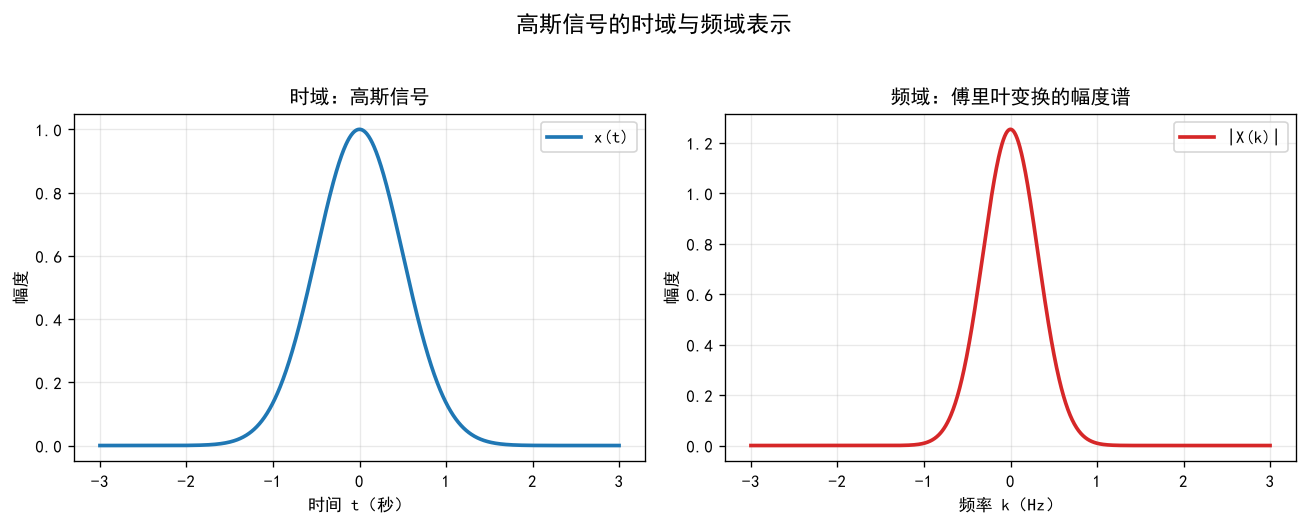

In [3]:
# 设定一个具体的标准差，以便生成数值曲线。
sigma_value = 0.5
x_t_numeric = x_t.subs(sigma, sigma_value)
X_k_numeric = X_k.subs(sigma, sigma_value)

# 将 SymPy 表达式转换为可接收 NumPy 数组的函数。
x_fun = sp.lambdify(t, x_t_numeric, modules='numpy')
X_fun = sp.lambdify(k, X_k_numeric, modules='numpy')

time_values = np.linspace(-3, 3, 1200)
frequency_values = np.linspace(-3, 3, 1200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(time_values, x_fun(time_values), color='#1f77b4', linewidth=2.2, label='x(t)')
axes[0].set_title('时域：高斯信号')
axes[0].set_xlabel('时间 t（秒）')
axes[0].set_ylabel('幅度')
axes[0].grid(True, alpha=0.28)
axes[0].legend()

axes[1].plot(
    frequency_values,
    np.abs(X_fun(frequency_values)),
    color='#d62728', linewidth=2.2, label='|X(k)|'
)
axes[1].set_title('频域：傅里叶变换的幅度谱')
axes[1].set_xlabel('频率 k（Hz）')
axes[1].set_ylabel('幅度')
axes[1].grid(True, alpha=0.28)
axes[1].legend()

fig.suptitle('高斯信号的时域与频域表示', fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

## 6. 傅里叶逆变换与重构误差

上一节中，`inverse_fourier_transform` 对频域表达式执行了逆变换。下图将原信号 $x(t)$ 与逆变换重构信号 $\hat{x}(t)$ 绘制在同一坐标轴上，并给出逐点误差。若符号推导正确，理论误差应为零；图中的误差仅可能来自浮点数计算精度。

C:\Users\yeshe\AppData\Local\Temp\ipykernel_13764\2779804057.py:27: UserWarning: Glyph 120 (x) missing from font(s) SimHei.
  fig.tight_layout()
d:\Source\Repos\Visual Studio Code\sensors_and_intelligent_detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 120 (x) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


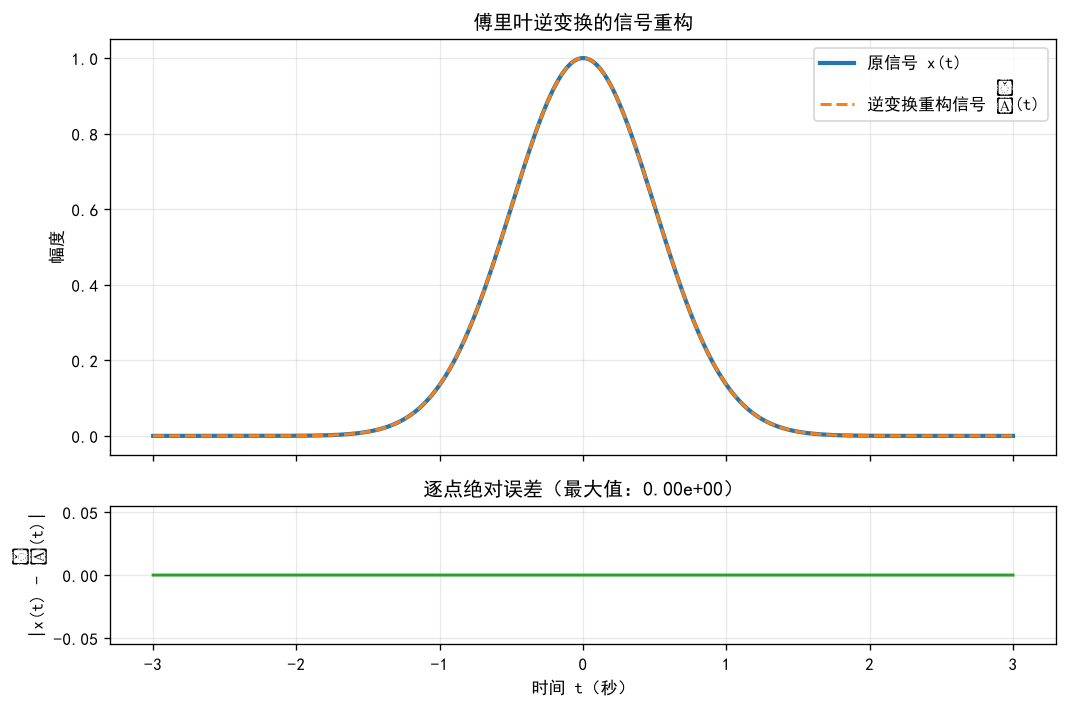

In [4]:
# 使用 SymPy 得到的逆变换表达式生成数值函数。
x_reconstructed_numeric = simplify(x_reconstructed.subs(sigma, sigma_value))
x_reconstructed_fun = sp.lambdify(t, x_reconstructed_numeric, modules='numpy')

original_values = np.real_if_close(x_fun(time_values))
reconstructed_values = np.real_if_close(x_reconstructed_fun(time_values))
error_values = np.abs(original_values - reconstructed_values)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])

axes[0].plot(time_values, original_values, color='#1f77b4', linewidth=2.5, label='原信号 x(t)')
axes[0].plot(
    time_values, reconstructed_values, color='#ff7f0e', linestyle='--',
    linewidth=1.8, label='逆变换重构信号 x̂(t)'
)
axes[0].set_title('傅里叶逆变换的信号重构')
axes[0].set_ylabel('幅度')
axes[0].grid(True, alpha=0.28)
axes[0].legend()

axes[1].plot(time_values, error_values, color='#2ca02c', linewidth=1.8)
axes[1].set_title(f'逐点绝对误差（最大值：{np.max(error_values):.2e}）')
axes[1].set_xlabel('时间 t（秒）')
axes[1].set_ylabel('|x(t) - x̂(t)|')
axes[1].grid(True, alpha=0.28)

fig.tight_layout()
plt.show()

## 7. 结论

本 Notebook 展示了以下要点：

1. **傅里叶变换**将时域信号表示为频率成分的连续叠加，便于考察频谱、带宽和滤波效果。
2. **傅里叶逆变换**从频域表示恢复时域信号，说明频谱包含恢复信号所需的信息。
3. 对高斯信号，SymPy 能够给出解析的傅里叶变换与逆变换；数值图像显示原信号和重构信号重合。
4. 使用中文字体配置后，Matplotlib 可在图表标题、坐标轴和图例中正确呈现中文标注。

### 参考资料

[1] SymPy Development Team. *Integral Transforms — SymPy Documentation*：https://docs.sympy.org/latest/modules/integrals/integrals.html

[2] A. V. Oppenheim, A. S. Willsky, with S. H. Nawab. *Signals and Systems*, 2nd ed., Prentice Hall, 1997.